# Evidence Retrieval Experiment Framework

This notebook acts as the central experiment framework for the dissertation.

It does not perform exploratory analysis of AVeriTeC; this is covered in the separate data inspection notebook. Instead, this notebook:

1. defines the experimental and reproducibility settings;
2. loads the prepared claims and candidate evidence collection;
3. executes each retrieval configuration through a common interface;
4. evaluates the resulting rankings using the same metrics;
5. records the configuration and environment associated with each run;

Retrieval implementations are contained in separate Python modules so that the experimental procedure remains consistent across methods.

## 1. Setup and Imports

### 1.1. Imports

In [19]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from datetime import datetime, timezone

import os
import sys
import json
import time
import random
import psutil
import threading
import subprocess
from time import perf_counter
import matplotlib.pyplot as plt

import nltk
import torch
import numpy as np
import pandas as pd
import transformers
import sentence_transformers
from tqdm.auto import tqdm
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetProcessUtilization, NVMLError


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.2. Resource Monitor Utils

In [20]:
class ResourceMonitor:
    def __init__(self, interval=1.0):
        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(0)
        self.pid = os.getpid()
        self.last_gpu_timestamp = 0
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.samples = []
        self.running = False
        self.thread = None

    def _sample(self):
        self.process.cpu_percent(None)

        start = time.perf_counter()



        while self.running:
            elapsed = time.perf_counter() - start
            cpu = (self.process.cpu_percent(None) / psutil.cpu_count())
            ram_gb = (self.process.memory_info().rss / 1024**3)
            gpu_gb = None
            gpu_util = self._gpu_process_utilisation() if torch.cuda.is_available() else None

            if torch.cuda.is_available():
                gpu_gb = (torch.cuda.memory_allocated() / 1024**3)

            self.samples.append({"time": elapsed, "cpu": cpu, "ram_gb": ram_gb, "gpu_util": gpu_util, "gpu_gb": gpu_gb})
            time.sleep(self.interval)

    def start(self):
        self.samples = []
        self.running = True
        self.thread = threading.Thread(target=self._sample, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False

        if self.thread is not None:
            self.thread.join()

        return pd.DataFrame(self.samples)

    def _gpu_process_utilisation(self):
        try:
            samples = nvmlDeviceGetProcessUtilization(self.gpu_handle, self.last_gpu_timestamp)

            gpu_util = 0.0

            for sample in samples:
                if sample.pid == self.pid:
                    gpu_util = float(sample.smUtil)

                    self.last_gpu_timestamp = max(self.last_gpu_timestamp, sample.timeStamp)

            return gpu_util

        except NVMLError:
            return 0.0


def plot_resources(data, title, smoothing_window=30):
    plot_data = data.copy()

    for column in ["cpu", "ram_gb", "gpu_gb", "gpu_util"]:
        if column in plot_data.columns:
            plot_data[column] = plot_data[column].rolling(window=smoothing_window, min_periods=1, center=True).mean()

    fig, ax = plt.subplots()

    ax.plot(plot_data["time"], plot_data["cpu"], label="CPU utilisation (%)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("CPU utilisation (%)")
    ax.set_title(title)
    ax.legend()

    plt.show()

    fig, ax = plt.subplots()

    ax.plot(plot_data["time"], plot_data["ram_gb"], label="RAM (GB)")

    if plot_data["gpu_gb"].notna().any():
        ax.plot(plot_data["time"], plot_data["gpu_gb"], label="GPU VRAM (GB)")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Memory (GB)")
    ax.set_title(title)
    ax.legend()

    plt.show()

    if "gpu_util" in plot_data.columns and plot_data["gpu_util"].notna().any():
        fig, ax = plt.subplots()

        ax.plot(plot_data["time"], plot_data["gpu_util"], label="GPU utilisation (%)")

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("GPU utilisation (%)")
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.legend()

        plt.show()

def summarise_resources(data):
    summary = {"mean_cpu_pct": data["cpu"].mean(), "peak_cpu_pct": data["cpu"].max(), "mean_ram_gb": data["ram_gb"].mean(), "peak_ram_gb": data["ram_gb"].max()}

    if data["gpu_util"].notna().any():
        summary["mean_gpu_pct"] = data["gpu_util"].mean()
        summary["peak_gpu_pct"] = data["gpu_util"].max()
    else:
        summary["mean_gpu_pct"] = None
        summary["peak_gpu_pct"] = None

    return summary

### 1.3. Local imports 

In [21]:
from fact_verification.data import CandidateStore, load_claims
from fact_verification.retrieval.bm25 import BM25Config, BM25Retriever

# left unused for practical reasons, DPR is too difficult to run on my hardware in the ideal setup and therefore has been dropped for a simpler dense retrieval model
# from fact_verification.retrieval.dpr import DPRConfig, DPRRetriever

from fact_verification.retrieval.dense import DenseConfig,DenseRetriever
from fact_verification.retrieval.hybrid import HybridConfig, HybridRetriever
from fact_verification.reranking.cross_encoder import CrossEncoderConfig, CrossEncoderReranker
from fact_verification.evaluation import evaluate_retrieval, evaluate_retrieval_per_claim

## 2. Experimental Configuration and Reproducibility

All variables capable of changing the experimental outcome are defined here.
Values should not be changed inside individual retrieval sections.

### 2.1. Main Experiment Configuration

In [22]:
EXPERIMENT = {
    "experiment_name": "initial_retriever_comparison",
    "seed": 67,

    "dataset": {
        "name": "AVeriTeC",
        "split": "dev",
        "revision": None,
        "root": os.environ.get("AVERITEC_ROOT"),
    },

    "candidates": {
        "retrieval_unit": "sentence",
        "chunk_size": None,
        "chunk_overlap": None,
    },

    "retrieval": {
        "retrieve_k": 100,
    },

    "evaluation": {
        "cutoffs": [1, 5, 10, 20, 50, 100],
    },

    "bm25": {
        "k1": 1.5,
        "b": 0.75,
        "epsilon": 0.25,
        "lowercase": False,
    },

    # left unused for practical reasons, DPR is too difficult to run on my hardware in the ideal setup and therefore has been dropped for a simpler dense retrieval model
    # "dpr": {
    #     "question_model":
    #         "facebook/dpr-question_encoder-multiset-base",
    #     "context_model":
    #         "facebook/dpr-ctx_encoder-multiset-base",

    #     "question_revision": None,
    #     "context_revision": None,

    #     "batch_size": 32,
    #     "max_length": 512,
    #     "use_title": False,
    #     "device": "cuda" if torch.cuda.is_available() else "cpu",
    # },

    "dense": {
        "model_name": ("sentence-transformers/multi-qa-MiniLM-L6-cos-v1"),
        "revision": None,
        "batch_size": 64,
        "device": (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        ),
    },

    "hybrid": {
        "method": "rrf",
        "fusion_depth": 100,
        "rrf_constant": 60,
        "alpha": 0.5,
    },

    "reranker": {
        "model_name":
            "cross-encoder/ms-marco-MiniLM-L6-v2",
        "revision": None,
        "batch_size": 32,
        "candidate_k": 100,
        "output_k": 20,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    },
    "run": {
        "mode": "full_test",
        "claims": 500,
    },
}
DATA_ROOT = EXPERIMENT["dataset"]["root"]

if DATA_ROOT is None:
    raise RuntimeError("AVERITEC_ROOT is not set \n set it to the root directory of the AVeriTeC data")

DATA_ROOT = Path(DATA_ROOT)



### 2.2. Resolve configuration / paths

In [23]:
DATA_ROOT_VALUE = EXPERIMENT["dataset"]["root"]

REPO_ROOT = Path.cwd().resolve().parent
RESULTS_ROOT = REPO_ROOT / "results"

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

if DATA_ROOT_VALUE is None:
    raise RuntimeError("AVERITEC_ROOT is not set \n set it to the root directory of the AVeriTeC data")

DATA_ROOT = Path(DATA_ROOT_VALUE).expanduser().resolve()

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"AVeriTeC data root does not exist: {DATA_ROOT}")

print(f"Repository root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Results root: {RESULTS_ROOT}")

Repository root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison
Data root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\.local_data\averitec\2ca9dee23a2a
Results root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results


### 2.3. Fix random seeds

In [24]:
SEED = EXPERIMENT["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### 2.4. Capture environment 

In [25]:
def get_git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            text=True
        ).strip()
    except Exception:
        return None


ENVIRONMENT = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "git_commit": get_git_commit(),
    "transformers_version": transformers.__version__,
    "sentence_transformers_version":sentence_transformers.__version__,
    "nltk_version": nltk.__version__,
}
pd.Series(ENVIRONMENT)

# NOTE: list not exhaustive, this is early expectations of what would be needed, should be updated later.

timestamp_utc                                     2026-08-18T09:47:35.893773+00:00
python_version                   3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:...
torch_version                                                         2.13.0+cu132
cuda_available                                                                True
cuda_version                                                                  13.2
gpu                                                        NVIDIA GeForce RTX 3060
git_commit                                8e677ade2052a9b84d205a6982de542c426ba4b9
transformers_version                                                        5.15.0
sentence_transformers_version                                                5.7.0
nltk_version                                                                3.10.2
dtype: object

### 2.5. Initialise Run Directory

In [26]:
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = RESULTS_ROOT / f"{run_timestamp}_{EXPERIMENT['run']['mode']}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Run directory:", RUN_DIR)

Run directory: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\20260818_104736_full_test


## 3. Load experimental data
Dataset structure and annotation characteristics are explored separately in
`01_averitec_data_inspection.ipynb`.  (NOTE: or whatever its called later)

Only the processed inputs required for retrieval are loaded here.

### 3.1. Initialise Claims and Candidate Store

In [27]:
claims = load_claims(root=DATA_ROOT, split=EXPERIMENT["dataset"]["split"])


if EXPERIMENT["run"]["mode"] == "pilot":
    claims = claims.sample(n=EXPERIMENT["run"]["claims"], random_state=EXPERIMENT["seed"]).sort_values("claim_id").reset_index(drop=True)

candidate_store = CandidateStore(root=DATA_ROOT, split=EXPERIMENT["dataset"]["split"], retrieval_unit=EXPERIMENT["candidates"]["retrieval_unit"], chunk_size=EXPERIMENT["candidates"]["chunk_size"], chunk_overlap=EXPERIMENT["candidates"]["chunk_overlap"])
print(f"Claims loaded: {len(claims):,}")
print(f"Knowledge-store claims: {len(candidate_store):,}")
print(f"Retrieval unit: {candidate_store.retrieval_unit}")
print(f"Knowledge store: {candidate_store.directory}")


Claims loaded: 500
Knowledge-store claims: 500
Retrieval unit: sentence
Knowledge store: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\.local_data\averitec\2ca9dee23a2a\knowledge_store\dev\output_dev


### 3.2. Candidate Generation Sanity Check

In [28]:
EXAMPLE_CLAIM_ID = claims.iloc[0]["claim_id"]

example_claim = claims.loc[claims["claim_id"] == EXAMPLE_CLAIM_ID, "claim"].iloc[0]
example_candidates = candidate_store.load_claim(EXAMPLE_CLAIM_ID)

print(f"Claim ID: {EXAMPLE_CLAIM_ID}")
print(f"Claim: {example_claim}")
print(f"Candidates generated: {len(example_candidates):,}")

display(example_candidates[["candidate_id", "source_url", "text", "sentence_start", "sentence_end"]].head(10))

Claim ID: 0
Claim: In a letter to Steve Jobs, Sean Connery refused to appear in an apple commercial.
Candidates generated: 534,488


,candidate_id,source_url,text,sentence_start,sentence_end
0,0:0:0,https://web.archive.org/web/20201129141238/htt...,"San Francisco, CA — It’s easy to appreciate iM...",0,0
1,0:0:1,https://web.archive.org/web/20201129141238/htt...,"In fact, Apple’s concerns over the brand-new c...",1,1
2,0:0:2,https://web.archive.org/web/20201129141238/htt...,The surprising story comes to light in iMacula...,2,2
3,0:0:3,https://web.archive.org/web/20201129141238/htt...,"As Ms. Woods spins the tale, it was just weeks...",3,3
4,0:0:4,https://web.archive.org/web/20201129141238/htt...,"Steve Jobs, a lifelong fan of James Bond (he’d...",4,4
5,0:0:5,https://web.archive.org/web/20201129141238/htt...,"“The ad was of dubious quality, clearly not on...",5,5
6,0:0:6,https://web.archive.org/web/20201129141238/htt...,"Though Steve had a thing for Sean Connery, the...",6,6
7,0:0:7,https://web.archive.org/web/20201129141238/htt...,Connery’s final rejection was accompanied by a...,7,7
8,0:0:8,https://web.archive.org/web/20201129141238/htt...,"Needless to say, iMac managed to “survive” wit...",8,8
9,0:0:9,https://web.archive.org/web/20201129141238/htt...,iMaculate Conception reveals a number of other...,9,9


#### 3.2.1. Candidate store sanity checks

In [29]:
assert not example_candidates.empty
assert example_candidates["candidate_id"].is_unique
assert example_candidates["text"].notna().all()

required_columns = {"claim_id", "candidate_id", "source_url", "text"}
missing = required_columns - set(example_candidates.columns)

assert not missing, (f"Candidate store is missing required fields: {sorted(missing)}")

## 4. Initialise Experimental Models

### 4.1. Initialise BM25 Retriever

In [30]:
bm25 = BM25Retriever(config=BM25Config(**EXPERIMENT["bm25"]))

print("BM25 retriever initialised.")

BM25 retriever initialised.


4.2. Initialise DPR

NOT USED ANYMORE

In [31]:
# dpr = DPRRetriever(config=DPRConfig(**EXPERIMENT["dpr"]))

# print("DPR initialised.")

# print("CUDA available:", torch.cuda.is_available())
# print("Configured device:", EXPERIMENT["dpr"]["device"])

### 4.2. Initialise Dense Retriever

In [32]:
dense = DenseRetriever(config=DenseConfig(**EXPERIMENT["dense"]))

print("Dense retriever initialised.")
print("Device:", dense.model.device)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5559.87it/s]


Dense retriever initialised.
Device: cuda:0


### 4.3. Initialise Hybrid Retriever
This section essentially just consumes the existing results, opposed to regenerating the experiment results for both BM25 and DPR

In [33]:
hybrid = HybridRetriever(lexical_retriever=bm25, dense_retriever=dense, config=HybridConfig(**EXPERIMENT["hybrid"]))

print("Hybrid retriever initialised.")

Hybrid retriever initialised.


### 4.4. Initialse Cross-Encoder Reranker
As with the hybrid retrieval, the reranker should consume candidate results from one of the first-stage systems

In [34]:
reranker_config = EXPERIMENT["reranker"]

cross_encoder = CrossEncoderReranker(
    config=CrossEncoderConfig(
        model_name=reranker_config["model_name"],
        revision=reranker_config["revision"],
        batch_size=reranker_config["batch_size"],
        device=reranker_config["device"],
    )
)

print("Cross-encoder reranker initialised.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5304.77it/s]


Cross-encoder reranker initialised.


## 5. Retrieval Experiments
Each retrieval method is executed using the same claims, candidate store and
retrieval depth defined in the experimental configuration.

### 5.1. Run BM25 

Also initialises runtime dictionaries (RUNTIMES, RESOURCE_USAGE, RUN_SUMMARY)

BM25Retriever: 100%|██████████| 500/500 [6:48:14<00:00, 48.99s/claim]  


BM25 results: 50,000
Runtime: 24494.97s


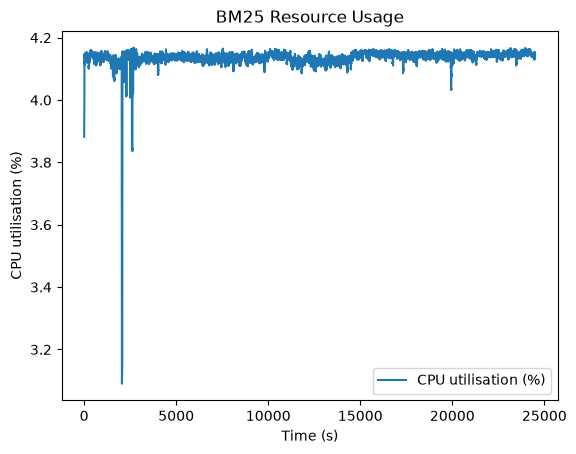

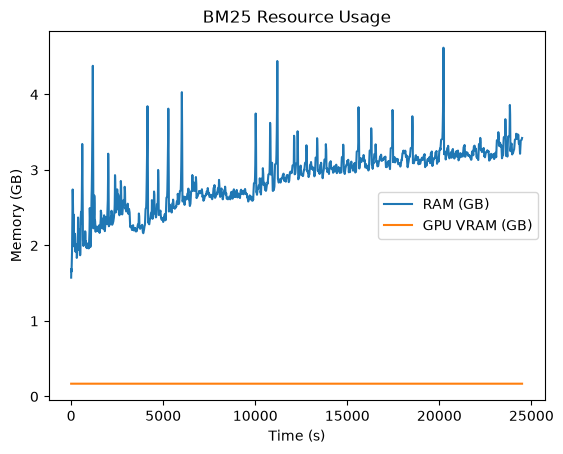

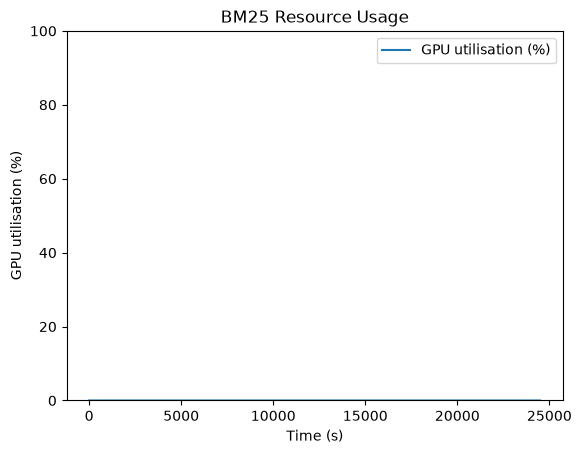

In [35]:
RUNTIMES = {}
RESOURCE_USAGE = {}
RUN_SUMMARY = {}

monitor = ResourceMonitor()
monitor.start()

start = perf_counter()

bm25_results = bm25.retrieve_batch(claims=claims, candidates=candidate_store, k=EXPERIMENT["retrieval"]["retrieve_k"])

RUNTIMES["bm25"] = perf_counter() - start
RESOURCE_USAGE["bm25"] = monitor.stop()

print(f"BM25 results: {len(bm25_results):,}")
print(f"Runtime: {RUNTIMES['bm25']:.2f}s")

plot_resources(RESOURCE_USAGE["bm25"], "BM25 Resource Usage")


RUN_SUMMARY["bm25"] = {"claims": len(claims), "results": len(bm25_results), "runtime_seconds": RUNTIMES["bm25"], **summarise_resources(RESOURCE_USAGE["bm25"])}

### 5.2. Run Dense

In [36]:
DENSE_CHECKPOINT = RUN_DIR / "dense_checkpoint.parquet"

if DENSE_CHECKPOINT.exists():
    dense_results = pd.read_parquet(DENSE_CHECKPOINT)

    completed_claims = set(dense_results["claim_id"].unique())

    print(f"Resuming dense retrieval: {len(completed_claims)} claims already complete.")
else:
    dense_results = pd.DataFrame()
    completed_claims = set()


remaining_claims = claims[~claims["claim_id"].isin(completed_claims)]


new_results = []

for _, claim in tqdm(remaining_claims.iterrows(), total=len(remaining_claims), desc="DenseRetriever", unit="claim"):
    claim_id = claim["claim_id"]

    claim_candidates = candidate_store.load_claim(claim_id)
    claim_candidates = claim_candidates.drop(columns=["claim_id"], errors="ignore")

    result = dense.retrieve(query=claim["claim"], candidates=claim_candidates, k=EXPERIMENT["retrieval"]["candidate_k"])

    result.insert(0, "claim_id", claim_id)
    new_results.append(result)

    # Save after every completed claim.
    checkpoint_results = pd.concat([dense_results, *new_results], ignore_index=True)

    checkpoint_results.to_parquet(DENSE_CHECKPOINT, index=False)


if new_results:
    dense_results = pd.concat([dense_results, *new_results], ignore_index=True)

dense_results = dense_results.sort_values(["claim_id", "rank"]).reset_index(drop=True)

print(f"Dense retrieval complete: {dense_results['claim_id'].nunique()} claims.")

DenseRetriever:   0%|          | 0/500 [00:01<?, ?claim/s]


KeyError: 'candidate_k'

### 5.3. Run Hybrid Fusion

In [ ]:
start = perf_counter()

hybrid_results = hybrid.fuse_batch(lexical_results=bm25_results, dense_results=dense_results, k=EXPERIMENT["retrieval"]["retrieve_k"])
RUNTIMES["hybrid_fusion"] = perf_counter() - start
print(f"Hybrid fusion runtime: {RUNTIMES['hybrid_fusion']:.4f}s")

RUNTIMES["hybrid_total"] = (RUNTIMES["bm25"] + RUNTIMES["dense"] + RUNTIMES["hybrid_fusion"])

HybridRetriever: 100%|██████████| 100/100 [00:00<00:00, 212.56claim/s]

Hybrid fusion runtime: 0.4790s


### 5.4. Run Cross-Encoder Reranking

CrossEncoderReranker: 100%|██████████| 100/100 [00:10<00:00,  9.82claim/s]


Reranked results: 2,000
Runtime: 10.19s


,claim_id,candidate_id,source_url,text,source_index,sentence_start,sentence_end,source_type,source_query,score,rank,method,first_stage_score,first_stage_rank,first_stage_method
0,11,11:31:8,https://thefederalist.com/2020/10/29/these-12-...,The mask dogma had many cracks in it from the ...,31,8,8,question_duplicate,Yinon Weiss claim about U.S. Surgeon General a...,9.903301,1,cross_encoder,0.016393,16,hybrid-rrf
1,11,11:143:2,https://www.vox.com/2020/3/31/21198132/coronav...,"US Surgeon General Jerome Adams tweeted, “STOP...",143,2,2,claim+question,The U.S. surgeon general and the Centers for D...,6.593999,2,cross_encoder,0.014493,25,hybrid-rrf
2,11,11:150:22,https://www.mlive.com/public-interest/2020/04/...,"In late February, U.S. Surgeon General Jerome ...",150,22,22,claim+question,The U.S. surgeon general and the Centers for D...,6.572618,3,cross_encoder,0.028694,3,hybrid-rrf
3,11,11:146:7,https://news.gallup.com/poll/310400/new-april-...,"In late February, at the early stage of the U....",146,7,7,claim+question,The U.S. surgeon general and the Centers for D...,6.555280,4,cross_encoder,0.011364,56,hybrid-rrf
4,11,11:28:36,https://theconversation.com/masks-help-stop-th...,"On Feb. 29, the U.S. surgeon general tweeted t...",28,36,36,question,Are masks effective in preventing people from ...,6.520189,5,cross_encoder,0.032522,1,hybrid-rrf


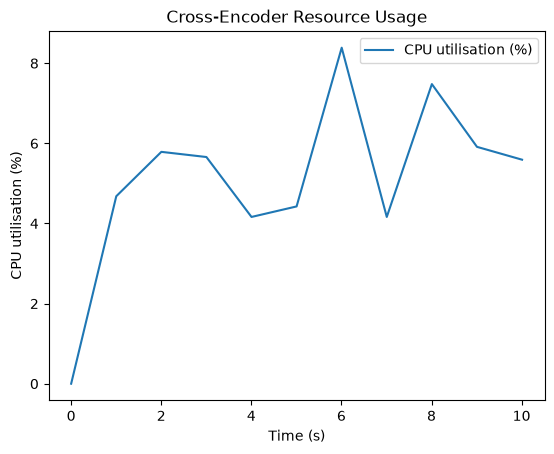

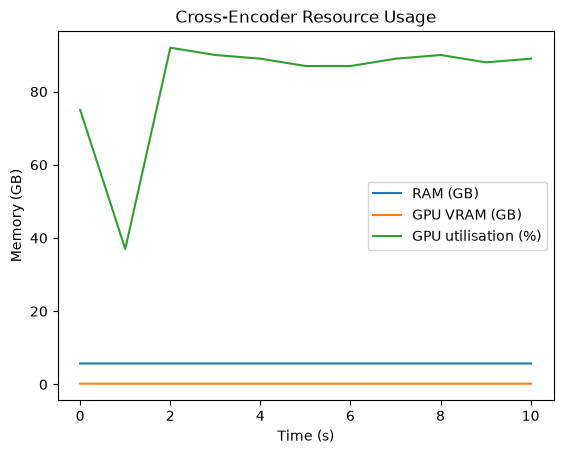

In [ ]:
monitor = ResourceMonitor()
monitor.start()

start = perf_counter()

reranked_results = cross_encoder.rerank_batch(claims=claims, candidates=hybrid_results, candidate_k=EXPERIMENT["reranker"]["candidate_k"], output_k=EXPERIMENT["reranker"]["output_k"])

RUNTIMES["cross_encoder"] = perf_counter() - start
RESOURCE_USAGE["cross_encoder"] = monitor.stop()

print(f"Reranked results: {len(reranked_results):,}")
print(f"Runtime: {RUNTIMES['cross_encoder']:.2f}s")

display(reranked_results.head())

plot_resources(RESOURCE_USAGE["cross_encoder"], "Cross-Encoder Resource Usage")

RUN_SUMMARY["cross_encoder"] = {"claims": len(claims), "results": len(reranked_results), "runtime_seconds": RUNTIMES["cross_encoder"], **summarise_resources(RESOURCE_USAGE["cross_encoder"])}

### 5.5.TEMP. Pilot Runtime Summary

temporary cell used to showcase full runtime of pilot, and calculate expected runtime, using original pilot runtimes as estimates to extrapolate to full length. wording is hard

In [ ]:
run_summary = pd.DataFrame(RUN_SUMMARY).T.reset_index(names="method")
display(run_summary)


scale_factor = (500 / len(claims))

run_summary["estimated_full_runtime_minutes"] = run_summary["runtime_seconds"] * scale_factor / 60
run_summary["estimated_full_runtime_hours"] = run_summary["estimated_full_runtime_minutes"] / 60

display(run_summary)

,method,claims,results,runtime_seconds,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct
0,bm25,100.0,10000.0,3089.429754,4.136879,4.287500,2.648604,5.617298,0.001011,2.0
1,dense,100.0,10000.0,40218.474043,5.393907,14.766667,3.658772,6.536934,89.826483,99.0
2,cross_encoder,100.0,2000.0,10.193091,5.113258,8.387500,5.702350,5.702995,83.000000,92.0


,method,claims,results,runtime_seconds,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,estimated_full_runtime_minutes
0,bm25,100.0,10000.0,3089.429754,4.136879,4.287500,2.648604,5.617298,0.001011,2.0,51.490496
1,dense,100.0,10000.0,40218.474043,5.393907,14.766667,3.658772,6.536934,89.826483,99.0,670.307901
2,cross_encoder,100.0,2000.0,10.193091,5.113258,8.387500,5.702350,5.702995,83.000000,92.0,0.169885


## 6. Comparative Retrieval Evaluation


###  6.1. Aggregate Retrieval Evaluation

In [ ]:
EVALUATION_SUMMARIES = {}

cutoffs = EXPERIMENT["evaluation"]["cutoffs"]
EVALUATION_SUMMARIES["bm25"] = evaluate_retrieval(claims=claims, results=bm25_results, cutoffs=cutoffs)
EVALUATION_SUMMARIES["dense"] = evaluate_retrieval(claims=claims, results=dense_results, cutoffs=cutoffs)
EVALUATION_SUMMARIES["hybrid"] = evaluate_retrieval(claims=claims, results=hybrid_results, cutoffs=cutoffs)

reranker_cutoffs = [k for k in cutoffs if k <= EXPERIMENT["reranker"]["output_k"]]

EVALUATION_SUMMARIES["cross_encoder"] = evaluate_retrieval(claims=claims, results=reranked_results, cutoffs=reranker_cutoffs)

### 6.2. Per-Claim Evaluation

In [ ]:
PER_CLAIM_METRICS = {}

PER_CLAIM_METRICS["bm25"] = evaluate_retrieval_per_claim(claims, bm25_results, cutoffs)
PER_CLAIM_METRICS["dense"] = evaluate_retrieval_per_claim(claims, dense_results, cutoffs)
PER_CLAIM_METRICS["hybrid"] = evaluate_retrieval_per_claim(claims, hybrid_results, cutoffs)
PER_CLAIM_METRICS["cross_encoder"] = evaluate_retrieval_per_claim(claims, reranked_results, reranker_cutoffs)

### 6.3. Evaluation Summay

In [ ]:
evaluation_table = pd.DataFrame(EVALUATION_SUMMARIES).T.reset_index(names="method")
display(evaluation_table)

### 6.4. Evaluation Sanity Checks

In [ ]:
assert all(summary["NumClaims"] == len(claims) for summary in EVALUATION_SUMMARIES.values())

evaluable_counts = {method: int(summary["NumEvaluableClaims"]) for method, summary in EVALUATION_SUMMARIES.items()}
print("Evaluable claims:", evaluable_counts)

assert len(set(evaluable_counts.values())) == 1

display(PER_CLAIM_METRICS["bm25"].head())

## 7. Save Experimental Run

### 7.1. Save Ranked Retrieval Results

In [ ]:
RESULT_SETS = {"bm25": bm25_results, "dense": dense_results, "hybrid": hybrid_results, "cross_encoder": reranked_results}

for method, results in RESULT_SETS.items():
    results.to_parquet(RUN_DIR / f"{method}_results.parquet", index=False)

### 7.2. Save Evaluation Results

In [ ]:
evaluation_table.to_csv(RUN_DIR / "evaluation_summary.csv", index=False)

for method, metrics in PER_CLAIM_METRICS.items():
    metrics.to_parquet(RUN_DIR / f"{method}_per_claim_metrics.parquet", index=False)

### 7.3. Save Resource Measurements

In [ ]:
for method, usage in RESOURCE_USAGE.items():
    if isinstance(usage, pd.DataFrame):
        usage.to_parquet(RUN_DIR / f"{method}_resource_usage.parquet", index=False)

pd.DataFrame(RUN_SUMMARY).T.to_csv(RUN_DIR / "resource_summary.csv")

### 7.4. Save Experiment Configuration

In [ ]:
def json_serialisable(value):
    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {key: json_serialisable(item) for key, item in value.items()}

    if isinstance(value, (list, tuple)):
        return [json_serialisable(item) for item in value]

    return value

with open(RUN_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(json_serialisable(EXPERIMENT), f, indent=2)

### 7.5. Verify Saved Run

In [ ]:
print(f"Saved experiment to: {RUN_DIR}")

for path in sorted(RUN_DIR.iterdir()):
    print(f"  {path.name}")